# Phase Diagram for System of Differential Equations

$$\dot{x}_1 = 2 - 3x_1 + x_2$$
$$\dot{x}_2 = 4 + x_1 - x_2$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.rcParams['figure.figsize'] = [10, 10]
plt.rcParams['font.size'] = 12
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'

## System Definition

In [ ]:
def system(X, t):
    x1, x2 = X
    dx1 = 2 - 3*x1 + x2
    dx2 = 4 + x1 - x2
    return [dx1, dx2]

# Equilibrium
x1_eq, x2_eq = 3, 7

# Jacobian matrix
A = np.array([[-3, 1],
              [1, -1]])

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Jacobian Matrix:")
print(A)
print(f"\nEigenvalues: λ₁ = {eigenvalues[0]:.6f}, λ₂ = {eigenvalues[1]:.6f}")
print(f"Analytical:  λ₁ = -2 + √2 ≈ {-2 + np.sqrt(2):.6f}, λ₂ = -2 - √2 ≈ {-2 - np.sqrt(2):.6f}")
print(f"\nEigenvector v₁: {eigenvectors[:, 0]}")
print(f"Eigenvector v₂: {eigenvectors[:, 1]}")

Jacobian Matrix:
[[-3  1]
 [ 1 -1]]

Eigenvalues: λ₁ = -3.414214, λ₂ = -0.585786
Analytical:  λ₁ = -2 + √2 ≈ -0.585786, λ₂ = -2 - √2 ≈ -3.414214

Eigenvector v₁: [-0.92387953  0.38268343]
Eigenvector v₂: [-0.38268343 -0.92387953]


## Generate Phase Diagram

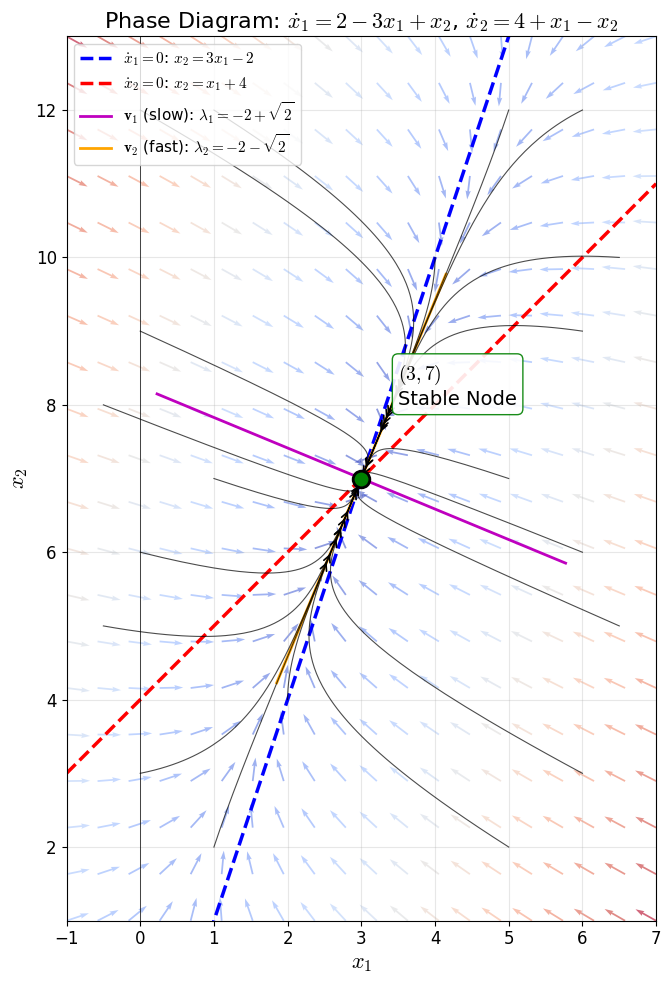


Saved: phase_diagram.pdf and phase_diagram.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot range
x1_min, x1_max = -1, 7
x2_min, x2_max = 1, 13

# Grid for vector field
x1_grid = np.linspace(x1_min, x1_max, 20)
x2_grid = np.linspace(x2_min, x2_max, 20)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Vector field
DX1 = 2 - 3*X1 + X2
DX2 = 4 + X1 - X2

# Normalize for better visualization
magnitude = np.sqrt(DX1**2 + DX2**2)
DX1_norm = DX1 / magnitude
DX2_norm = DX2 / magnitude

# Plot vector field
ax.quiver(X1, X2, DX1_norm, DX2_norm, magnitude, cmap='coolwarm', alpha=0.6, scale=25)

# Nullclines
x1_nullcline = np.linspace(x1_min, x1_max, 100)
x2_nullcline_1 = 3*x1_nullcline - 2  # dx1/dt = 0: x2 = 3x1 - 2
x2_nullcline_2 = x1_nullcline + 4     # dx2/dt = 0: x2 = x1 + 4

ax.plot(x1_nullcline, x2_nullcline_1, 'b--', linewidth=2.5, label=r'$\dot{x}_1 = 0$: $x_2 = 3x_1 - 2$')
ax.plot(x1_nullcline, x2_nullcline_2, 'r--', linewidth=2.5, label=r'$\dot{x}_2 = 0$: $x_2 = x_1 + 4$')

# Eigenvector directions through equilibrium
t_eigen = np.linspace(-3, 3, 100)

# v1: slower eigenvalue λ₁ = -2 + √2
v1 = eigenvectors[:, 0]
eigen_line1_x1 = x1_eq + t_eigen * v1[0]
eigen_line1_x2 = x2_eq + t_eigen * v1[1]

# v2: faster eigenvalue λ₂ = -2 - √2
v2 = eigenvectors[:, 1]
eigen_line2_x1 = x1_eq + t_eigen * v2[0]
eigen_line2_x2 = x2_eq + t_eigen * v2[1]

ax.plot(eigen_line1_x1, eigen_line1_x2, 'm-', linewidth=2, 
        label=rf'$\mathbf{{v}}_1$ (slow): $\lambda_1 = -2+\sqrt{{2}}$')
ax.plot(eigen_line2_x1, eigen_line2_x2, color='orange', linestyle='-', linewidth=2,
        label=rf'$\mathbf{{v}}_2$ (fast): $\lambda_2 = -2-\sqrt{{2}}$')

# Trajectories
t_forward = np.linspace(0, 10, 500)

initial_conditions = [
    (0, 3), (0, 6), (0, 9), (0, 12),
    (6, 3), (6, 6), (6, 9), (6, 12),
    (1, 2), (5, 2), (1, 12), (5, 12),
    (-0.5, 5), (-0.5, 8), (6.5, 5), (6.5, 10),
    (2, 4), (4, 10), (1, 7), (5, 7)
]

for x1_0, x2_0 in initial_conditions:
    sol = odeint(system, [x1_0, x2_0], t_forward)
    ax.plot(sol[:, 0], sol[:, 1], 'k-', linewidth=0.8, alpha=0.7)
    # Arrow at midpoint
    mid = len(sol) // 4
    if mid > 0 and mid < len(sol) - 1:
        dx = sol[mid+1, 0] - sol[mid, 0]
        dy = sol[mid+1, 1] - sol[mid, 1]
        ax.annotate('', xy=(sol[mid+1, 0], sol[mid+1, 1]), 
                    xytext=(sol[mid, 0], sol[mid, 1]),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

# Equilibrium point
ax.plot(x1_eq, x2_eq, 'ko', markersize=12, markerfacecolor='green', markeredgewidth=2, zorder=10)
ax.annotate(f'$({x1_eq}, {x2_eq})$\nStable Node', xy=(x1_eq, x2_eq), xytext=(x1_eq + 0.5, x2_eq + 1),
            fontsize=14, ha='left',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='green', alpha=0.9))

# Formatting
ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_xlabel(r'$x_1$', fontsize=16)
ax.set_ylabel(r'$x_2$', fontsize=16)
ax.set_title(r'Phase Diagram: $\dot{x}_1 = 2 - 3x_1 + x_2$, $\dot{x}_2 = 4 + x_1 - x_2$', fontsize=16)
ax.legend(loc='upper left', fontsize=11)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('phase_diagram.pdf', dpi=300, bbox_inches='tight')
plt.savefig('phase_diagram.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: phase_diagram.pdf and phase_diagram.png")

## Summary

**Equilibrium:** $(x_1^*, x_2^*) = (3, 7)$

**Eigenvalues:**
- $\lambda_1 = -2 + \sqrt{2} \approx -0.586$ (slower decay)
- $\lambda_2 = -2 - \sqrt{2} \approx -3.414$ (faster decay)

**Classification:** Both eigenvalues real and negative → **Stable Node**

**Behavior:** All trajectories converge to $(3, 7)$ as $t \to \infty$